# Credit Card Fraud Detection - Exploratory Data Analysis
### Designed by Aniket Sawant

## Project Overview
This notebook covers exploratory data analysis of the ULB Credit Card Fraud Detection dataset containing 284,807 transactions over a 48 hour period. The dataset is severely imbalanced with only 492 fraudulent transactions representing 0.17% of all records, making accuracy a completely unreliable evaluation metric for any model trained on this data. 

## Top Findings
Analysis of transaction amounts reveals fraudsters deliberately keep transactions below 500 to avoid detection a behaviour known as structuring. 
Time pattern analysis shows the fraud rate is four times higher during low activity periods compared to peak hours, suggesting fraudsters deliberately exploit reduced monitoring windows.

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os
from matplotlib.patches import Patch


df = pd.read_csv("/Users/aniketsawant/FraudDetection/fraud-detection-algorithm/data/raw/creditcard.csv")

# Column and row count
print(df.shape)
# Column names
print(df.columns)
# Statistical information of the data
print(df.describe())
# Null count
print(df.isna().sum())
pd.reset_option('all')

(284807, 31)
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

 

/var/folders/3h/xjqm1f393sgf813dj7qdsx2m0000gn/T/ipykernel_63032/549285252.py:19: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
/var/folders/3h/xjqm1f393sgf813dj7qdsx2m0000gn/T/ipykernel_63032/549285252.py:19: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


The class column represents whether this record is fraudulent or not, there are 284315 records of 0 and only 492 records of 1. 

1 represnts fradulent transaction. This highly imbalanced data is being represented by class column. If there were more fradulent transactions that mean would have shifted more towards 1 than 0

The distribution of amount is skewed towards lower values that means there are a lot of day to day transactions happening on the credit card, while there are few high value transactions happening but these are quite rare.

The time indicates that this data is for total 2 days, it represents the time elapsed in seconds since the very first transaction in the dataset.

Having null values in the data would affect in modelling the relationship between the attribute with null values and the output variable. If any important column has null values then we might have impute or interpolate or even drop the column which might result in losing valuable information

In [16]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [19]:
df['Amount'].loc[df['Amount']>=100].value_counts()

Amount
100.00    877
150.00    497
200.00    478
144.00    414
158.00    377
         ... 
252.98      1
196.62      1
147.12      1
940.00      1
337.54      1
Name: count, Length: 23149, dtype: int64

In [21]:
df['Time'].value_counts()

Time
163152.0    36
64947.0     26
68780.0     25
3767.0      21
3770.0      20
            ..
127750.0     1
62260.0      1
62259.0      1
127753.0     1
172792.0     1
Name: count, Length: 124592, dtype: int64

/var/folders/3h/xjqm1f393sgf813dj7qdsx2m0000gn/T/ipykernel_63032/2402587612.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


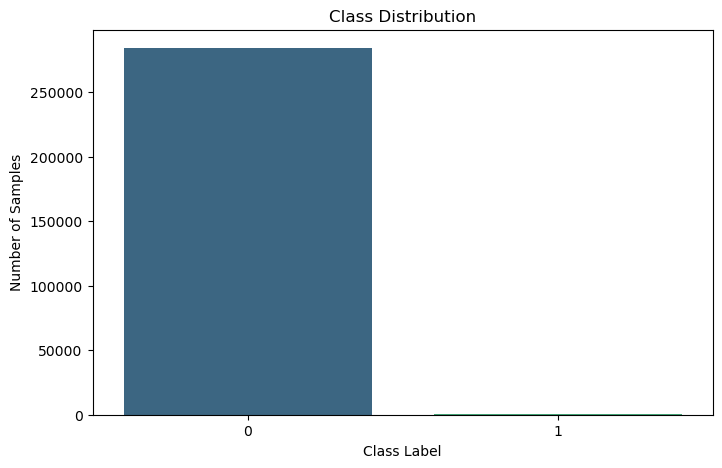

In [259]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')

output_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "outputs")
os.makedirs(output_dir, exist_ok=True)
path = os.path.join(output_dir, "Class distribution.png")
plt.savefig(path, dpi=300)

So there are total 284315 0s and 492 1s, that means the probability of any transaction being fraudulent is 0.17%, this data is highly skewed. For a model to accurately predict any outcome it needs to be trained on unbiased data and since there is so much bias towards non-fraudulent transactions in this data our model would not be trained properly and depending upon accuracy for model performance would be a waste of time.

/var/folders/3h/xjqm1f393sgf813dj7qdsx2m0000gn/T/ipykernel_63032/2238838247.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x='Amount', data=frd_df, bins=5,palette='viridis')
/var/folders/3h/xjqm1f393sgf813dj7qdsx2m0000gn/T/ipykernel_63032/2238838247.py:18: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x='Amount', data=leg_df, bins=100,palette='viridis')


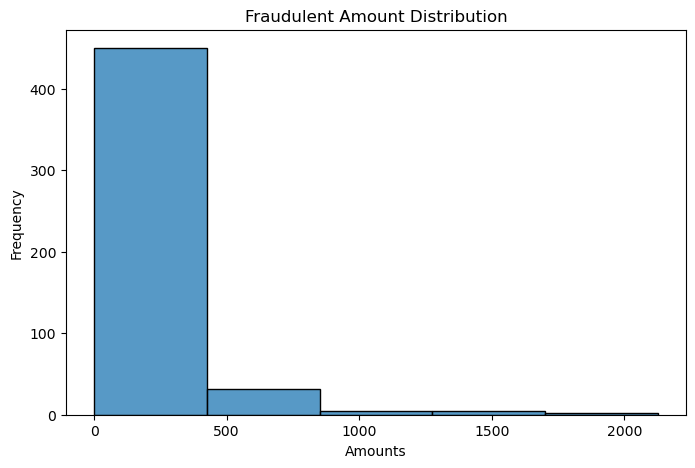

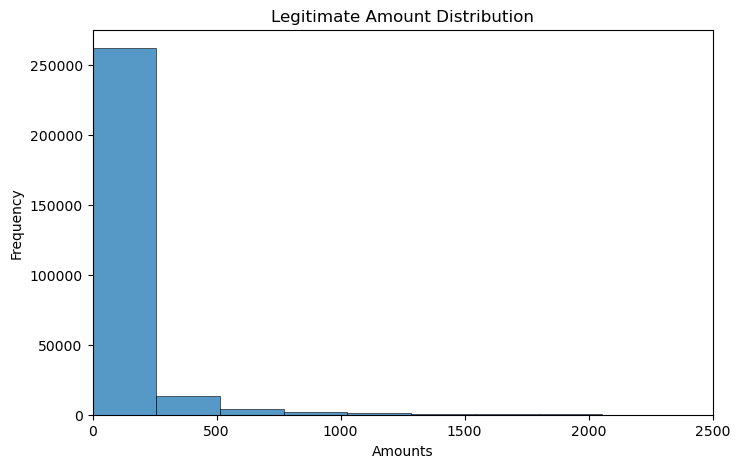

In [169]:
frd_df = df.loc[df['Class']==1]

plt.figure(figsize = (8,5))
sns.histplot(x='Amount', data=frd_df, bins=5,palette='viridis')
plt.title('Fraudulent Amount Distribution')
plt.xlabel('Amounts')
plt.ylabel('Frequency')


output_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "outputs")
os.makedirs(output_dir, exist_ok=True)
path = os.path.join(output_dir, "Fraudulent transactions amount distribution.png")
plt.savefig(path, dpi=300)

leg_df = df.loc[df['Class']==0]

plt.figure(figsize = (8,5))
sns.histplot(x='Amount', data=leg_df, bins=100,palette='viridis')
plt.xlim(0, 2500) 
plt.title('Legitimate Amount Distribution')
plt.xlabel('Amounts')
plt.ylabel('Frequency')

output_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "outputs")
os.makedirs(output_dir, exist_ok=True)
path = os.path.join(output_dir, "Legitimate transactions amount distribution.png")
plt.savefig(path, dpi=300)

A lot of fradulent transactions happened between the amount of 0 to 500 that means people are using these stolen cards for everyday transactions rather than one big transaction so they would not get noticed. In case of legitimate transactions as we have observed earlier people are using these cards for their day to day transactions.

Fraudulent transactions — concentrated between 0 and 500, very few above that. Maximum is around 2,100.
Legitimate transactions — also concentrated at low amounts but the tail extends all the way to 25,000. Legitimate cardholders make occasional large purchases.

Fraudulent transactions almost never exceed 2,500. Legitimate transactions do regularly. Fraudsters deliberately keep amounts low to stay under bank alert thresholds. This is a known real-world behaviour called structuring deliberately keeping transactions below amounts that trigger automatic review.

The Amount feature does carry some signal, just not the obvious one. It's not that fraud happens at high amounts. It's that fraud almost never happens at very high amounts while legitimate transactions sometimes do.

In [173]:
df['Time_in_hours'] = df['Time']/(60*60)
df['Time_in_hours'] = df['Time_in_hours'].astype(int)
leg_df = df.loc[df['Class']==0]
frd_df = df.loc[df['Class']==1]

/var/folders/3h/xjqm1f393sgf813dj7qdsx2m0000gn/T/ipykernel_63032/353423308.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x='Time_in_hours', data=leg_df, bins=10,palette='viridis')
/var/folders/3h/xjqm1f393sgf813dj7qdsx2m0000gn/T/ipykernel_63032/353423308.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x='Time_in_hours', data=frd_df, bins=10,palette='viridis')


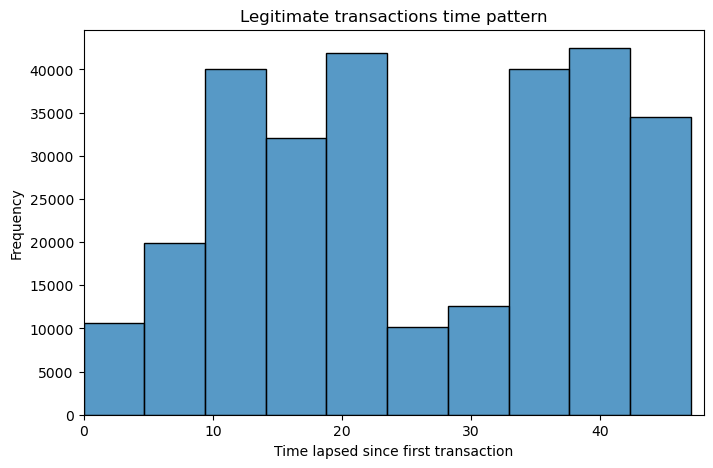

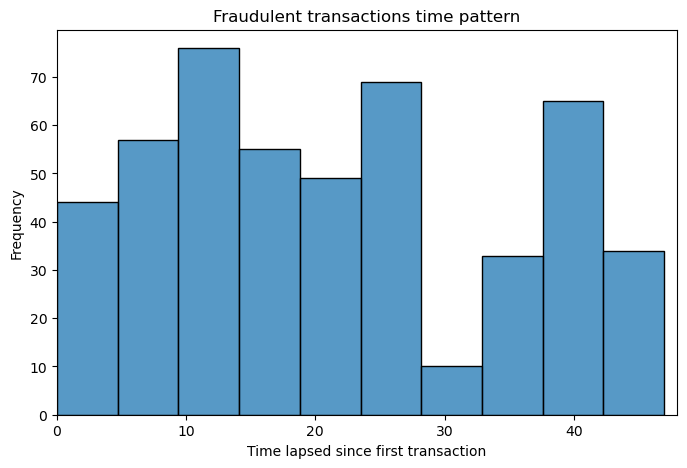

In [175]:
plt.figure(figsize = (8,5))
sns.histplot(x='Time_in_hours', data=leg_df, bins=10,palette='viridis')
plt.xlim(0, 48) 
plt.title('Legitimate transactions time pattern')
plt.xlabel('Time lapsed since first transaction')
plt.ylabel('Frequency')
output_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "outputs")
os.makedirs(output_dir, exist_ok=True)
path = os.path.join(output_dir, "Legitimate transactions time pattern analysis.png")
plt.savefig(path, dpi=300)


plt.figure(figsize = (8,5))
sns.histplot(x='Time_in_hours', data=frd_df, bins=10,palette='viridis')
plt.xlim(0, 48) 
plt.title('Fraudulent transactions time pattern')
plt.xlabel('Time lapsed since first transaction')
plt.ylabel('Frequency')
output_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "outputs")
os.makedirs(output_dir, exist_ok=True)
path = os.path.join(output_dir, "Fraudulent transactions time pattern analysis.png")
plt.savefig(path, dpi=300)

In [181]:
count_between_10_to_20 = df.loc[(df['Time_in_hours']>=10) & (df['Time_in_hours']<=20) & (df['Class']==1)].shape[0]
count_between_25_to_30 = df.loc[(df['Time_in_hours']>=25) & (df['Time_in_hours']<=30) & (df['Class']==1)].shape[0]

transaction_count_10_to_20 = df.loc[(df['Time_in_hours']>=10) & (df['Time_in_hours']<=20)].shape[0]
transaction_count_25_to_30 = df.loc[(df['Time_in_hours']>=25) & (df['Time_in_hours']<=30)].shape[0]

# Fraud rate for transactions happening between 10 hours to 20 hours
fraudrate_10_20 = count_between_10_to_20/transaction_count_10_to_20
print(count_between_10_to_20)
print(transaction_count_10_to_20)
print(fraudrate_10_20*100)

# Fraud rate for transactions happening between 25 hours to 30 hours
fraudrate_25_30 = count_between_25_to_30/transaction_count_25_to_30
print(count_between_25_to_30)
print(transaction_count_25_to_30)
print(fraudrate_25_30*100)

146
89236
0.16361109865973372
71
10132
0.7007500986971971


So there are total 89236 transactions happened between hour 10 to 20 which are the busiest hours of the data and only 146 of them were fraudulent so the rate is 0.16% which is almost exact as our database average

While between 25 to 30 total 10132 transactions happened and only 71 of them were fraudulent so the rate here is 0.7% which is four times higher than the average. What we could assume here is that this is a nighttime and there will be lower monitoring on the transactions unless the system is automated but in our case let's assume it's not as we are building an automated solution for this problem. Nighttime means less staff to monitor the transaction, cardholder might not be aware about the fraud, response time would be delayed

Class    1.000000
V17     -0.326481
V14     -0.302544
V12     -0.260593
V10     -0.216883
V16     -0.196539
V3      -0.192961
V7      -0.187257
V11      0.154876
V4       0.133447
Name: Class, dtype: float64


<Axes: >

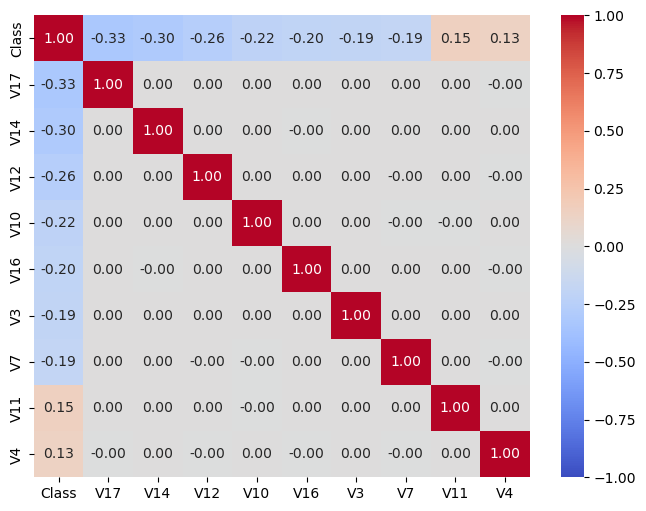

In [185]:
# 1. Calculate the initial correlation matrix
corr_matrix = df.corr()

# 2. Get top features correlated with the 'target' column
# We use abs() to capture strong negative correlations (e.g., -0.9)
target_corr = corr_matrix['Class'].abs().sort_values(ascending=False)
# Select the top 10 features (including the target itself)
top_feature_names = target_corr.head(10).index

# 3. Create the final correlation matrix with only these features
top_corr_matrix = df[top_feature_names].corr()

print(top_corr_matrix['Class'])
plt.figure(figsize=(8, 6))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)


V17 and V14 are negatively correlated means any decrease in these values could increase the probability of fraud. Also V11 and V4 directly correlates to the fraud, when they increase the probability of fraud increases. Correlation-based approach would not be sufficient here because none of these features clearly has strong relation with the output variable so we will need more sophisticated model for prediction.

A Linear model is dependent on the coefficients which makes the linear expression and since these attributes are not strongly related to output variable the linear expression would not be able to predict the outcome with strong probability which is why we need tree based models because they don't use these coefficients for prediction.

Tree based models like Random Forest and XGBoost don't look at features individually in isolation. They look at combinations of features together. A single feature with 0.33 correlation might be weak alone, but when the model says "V17 is low AND V14 is low AND Amount is below 500 simultaneously" that combination becomes a much stronger fraud signal than any single feature could provide.

This is called feature interaction, tree based models capture it naturally through their branching structure while linear models can only capture it if you explicitly engineer interaction terms yourself.

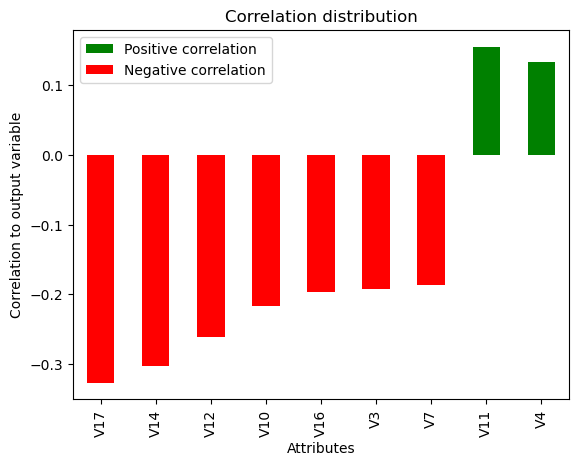

In [257]:
colors = ['red' if x < 0 else 'green' for x in top_corr_matrix['Class'][1:].sort_values(ascending=False, key = abs)]
top_corr_matrix['Class'][1:].sort_values(ascending=False , key = abs).plot(kind = "bar", color = colors)
plt.title('Correlation distribution')
plt.ylabel('Correlation to output variable')
plt.xlabel('Attributes')
legend_elements = [Patch(facecolor='green', label='Positive correlation'),
                   Patch(facecolor='red', label='Negative correlation')]
plt.legend(handles=legend_elements)
output_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "outputs")
os.makedirs(output_dir, exist_ok=True)
path = os.path.join(output_dir, "Correlation distribution.png")
plt.savefig(path, dpi=300)